In [99]:
# Importation of necessary libraries
import os
import db_dtypes
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "my-project-ecommerce1-a9cefc290e72.json"
from google.cloud import bigquery
import pandas as pd
import sys
!{sys.executable} -m pip install db-dtypes
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [100]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV, train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve



### **Big Query and Structured Language Query (SQL)**

In [101]:
# Create a BigQuery client
client = bigquery.Client(project="my-project-ecommerce1")
dataset_ref = client.dataset("ga4_obfuscated_sample_ecommerce", project="bigquery-public-data")
dataset = client.get_dataset(dataset_ref)

In [102]:
# List all tables in the dataset
list_of_tables = [table.table_id for table in client.list_tables(dataset)]
list_of_tables_df = pd.DataFrame(list_of_tables, columns=['table_id'])
print(list_of_tables_df.head())
list_of_tables_df.shape

          table_id
0  events_20201101
1  events_20201102
2  events_20201103
3  events_20201104
4  events_20201105


(92, 1)

In [103]:
# Load the events_20201116 table into a DataFrame to take a look at the data
table_ref = dataset_ref.table('events_20201116')
table = client.get_table(table_ref)
df_events = client.list_rows(table).to_dataframe()
print(df_events.head())


c:\Users\HP\Documents\L3_Math_Info\Projets_Code\bq_ecommerce_project\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  event_date  ...  items
0   20201116  ...     []
1   20201116  ...     []
2   20201116  ...     []
3   20201116  ...     []
4   20201116  ...     []

[5 rows x 23 columns]


In [104]:
# Define a function to run a query and return the results as a DataFrame
def run_query(query):
    safe_config = bigquery.QueryJobConfig(maximum_bytes_billed=10**10)
    query_job = client.query(query, job_config=safe_config)
    query_results = query_job.to_dataframe()
    return query_results



In [105]:
# collect the column names of the DataFrame for checking the features and target variable
df_events.columns

Index(['event_date', 'event_timestamp', 'event_name', 'event_params',
       'event_previous_timestamp', 'event_value_in_usd',
       'event_bundle_sequence_id', 'event_server_timestamp_offset', 'user_id',
       'user_pseudo_id', 'privacy_info', 'user_properties',
       'user_first_touch_timestamp', 'user_ltv', 'device', 'geo', 'app_info',
       'traffic_source', 'stream_id', 'platform', 'event_dimensions',
       'ecommerce', 'items'],
      dtype='str')

In [106]:
# Create a query to extract features and the target variable from the GA4 e-commerce dataset
query = """
        SELECT user_pseudo_id,
            
            -- 1. Contextual Features (Device, Location, Traffic source)
            MAX(device.category) AS device_category,
            MAX(geo.country) AS country,
            MAX(traffic_source.medium) AS traffic_medium,
            
            -- 2. Behavioral Features (Action counters)
            COUNT(CASE WHEN event_name = 'view_item' THEN 1 END) AS count_view_item,
            COUNT(CASE WHEN event_name = 'add_to_cart' THEN 1 END) AS count_add_to_cart,
            COUNT(CASE WHEN event_name = 'begin_checkout' THEN 1 END) AS count_begin_checkout,
            
            -- 3. TARGET VARIABLE : Did the user make at least one purchase? (1 = Yes, 0 = No)
            MAX(CASE WHEN event_name = 'purchase' THEN 1 ELSE 0 END) AS target_has_purchased

        FROM `bigquery-public-data.ga4_obfuscated_sample_ecommerce.events_*`
        WHERE _TABLE_SUFFIX BETWEEN '20201101' AND '20201130'
        AND user_pseudo_id IS NOT NULL
        GROUP BY user_pseudo_id
                """
eco_df = run_query(query)


c:\Users\HP\Documents\L3_Math_Info\Projets_Code\bq_ecommerce_project\venv\Lib\site-packages\google\cloud\bigquery\table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


In [107]:
# Display the first few rows of the resulting DataFrame and its shape
print(eco_df.head())
eco_df.shape

       user_pseudo_id  ... target_has_purchased
0  1072394.8069470636  ...                    0
1  1133611.5613010659  ...                    0
2  1152223.7341214795  ...                    0
3  1166460.3574131716  ...                    0
4  1222933.3634262192  ...                    0

[5 rows x 8 columns]


(79421, 8)

In [108]:
# Save the resulting DataFrame to a CSV file
eco_df.to_csv('ecommerce_users_raw.csv', index=False)

### **Exploratory Data Analysis (EDA)**

In [109]:
# Beginning of EDA (Exploratory Data Analysis) and Feature Engineering
e_commerce_df = pd.read_csv('ecommerce_users_raw.csv')
e_commerce_df.head()

,user_pseudo_id,device_category,country,traffic_medium,count_view_item,count_add_to_cart,count_begin_checkout,target_has_purchased
0,1.072395e+06,desktop,China,(none),0,0,0,0
1,1.133612e+06,mobile,United States,<Other>,0,0,0,0
2,1.152224e+06,desktop,United States,referral,0,0,0,0
3,1.166460e+06,tablet,United States,<Other>,3,0,0,0
4,1.222933e+06,desktop,United States,organic,56,0,2,0


In [110]:
# Display the information about the DataFrame
e_commerce_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 79421 entries, 0 to 79420
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   user_pseudo_id        79421 non-null  float64
 1   device_category       79421 non-null  str    
 2   country               79421 non-null  str    
 3   traffic_medium        79421 non-null  str    
 4   count_view_item       79421 non-null  int64  
 5   count_add_to_cart     79421 non-null  int64  
 6   count_begin_checkout  79421 non-null  int64  
 7   target_has_purchased  79421 non-null  int64  
dtypes: float64(1), int64(4), str(3)
memory usage: 6.6 MB


In [111]:
# Distrubition of Traffic medium by Purchase Status
e_commerce_df.groupby('traffic_medium')['target_has_purchased'].value_counts(normalize=True).unstack() * 100

target_has_purchased,0,1
traffic_medium,,
(data deleted),96.896217,3.103783
(none),98.928637,1.071363
<Other>,98.913134,1.086866
cpc,98.763736,1.236264
organic,98.457045,1.542955
referral,95.961051,4.038949


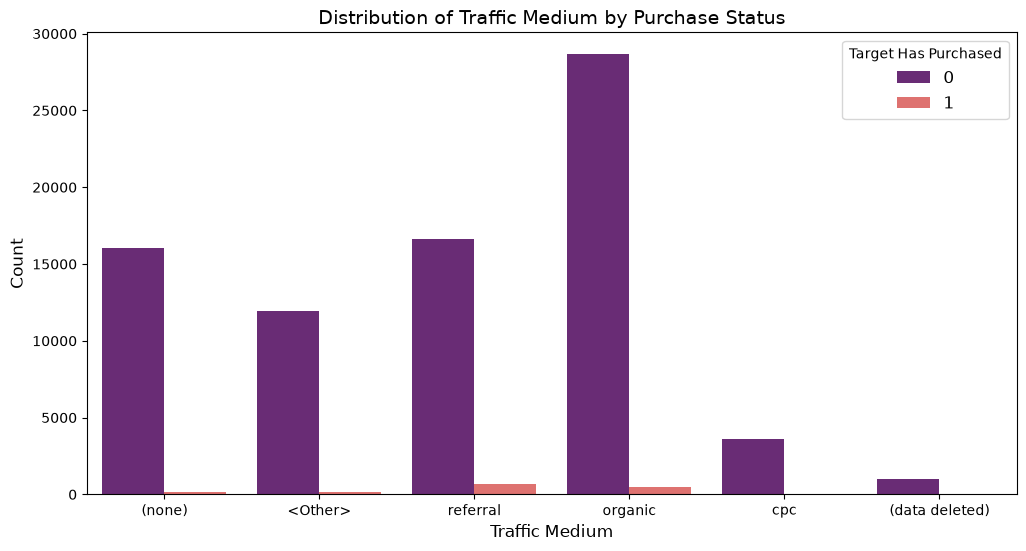

In [112]:
plt.figure(figsize=(12,6))
sns.countplot(data=e_commerce_df, x='traffic_medium', hue='target_has_purchased', palette='magma')
plt.title('Distribution of Traffic Medium by Purchase Status', fontsize = 14)
plt.xlabel('Traffic Medium', fontsize = 12)
plt.ylabel('Count', fontsize = 12)
plt.legend(title='Target Has Purchased', fontsize = 12)

### Analysis of Traffic Medium
While organic traffic brings the highest absolute volume of visitors to the website, analysis shows that the referral channel achieves the highest conversion rate (over 4%). This indicates that external recommendations or partner links bring more qualified, purchase-ready users, while organic traffic requires optimization to improve its conversion efficiency.

In [113]:
# Calculating average product views grouped by purchase status
view_comparison = e_commerce_df.groupby('target_has_purchased')['count_view_item'].mean()
print(view_comparison)

target_has_purchased
0     1.532219
1    19.122715
Name: count_view_item, dtype: float64


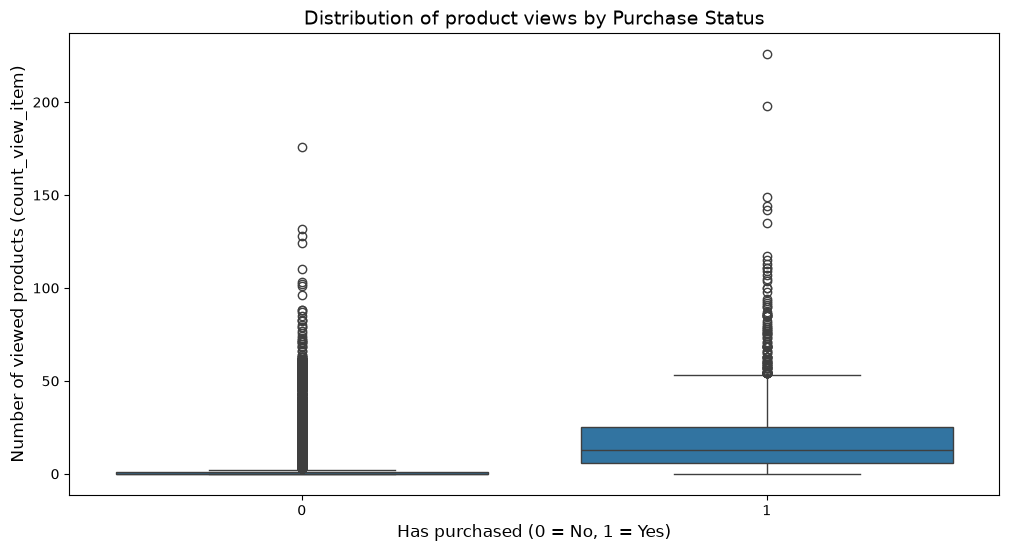

In [114]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=e_commerce_df, x='target_has_purchased', y='count_view_item')
plt.title('Distribution of product views by Purchase Status', fontsize = 14)
plt.xlabel('Has purchased (0 = No, 1 = Yes)', fontsize = 12)
plt.ylabel('Number of viewed products (count_view_item)', fontsize = 12)
plt.show()

### Analysis of Product Views 
The analysis shows a significant difference between users. Users who did not purchase (0) viewed an average of 1.53 products, while those who purchased (1) viewed an average of 19.12 products. This indicates that high engagement and deep catalog exploration are strong indicators of a future purchase.

In [115]:
cart_comparison = e_commerce_df.groupby('target_has_purchased')['count_add_to_cart'].mean()
print(cart_comparison)

target_has_purchased
0    0.056105
1    2.156658
Name: count_add_to_cart, dtype: float64


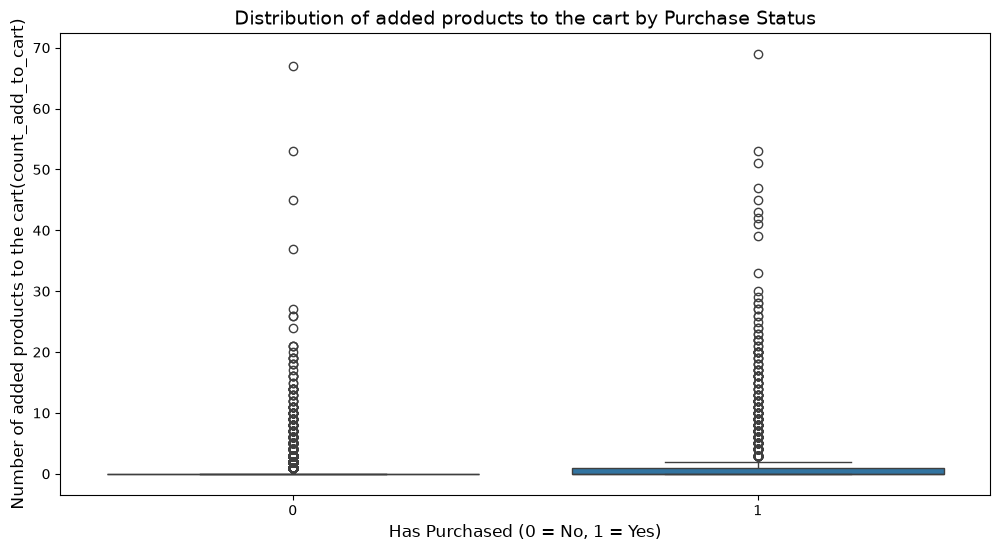

In [116]:
plt.figure(figsize=(12,6))
sns.boxplot(data=e_commerce_df, x='target_has_purchased', y='count_add_to_cart')
plt.title('Distribution of added products to the cart by Purchase Status', fontsize = 14)
plt.xlabel('Has Purchased (0 = No, 1 = Yes)', fontsize = 12)
plt.ylabel('Number of added products to the cart(count_add_to_cart)', fontsize = 12)
plt.show()


### Analysis Cart Additions 
The results reveal that adding items to the cart is a near-mandatory step for buying. Buyers added an average of 2.15 products to their cart, whereas non-buyers averaged close to zero (0.05). This confirms that a cart addition is a powerful predictor for our machine learning model.

In [117]:
checkout_comparison = e_commerce_df.groupby('target_has_purchased')['count_begin_checkout'].mean()
print(checkout_comparison)

target_has_purchased
0    0.060240
1    3.168407
Name: count_begin_checkout, dtype: float64


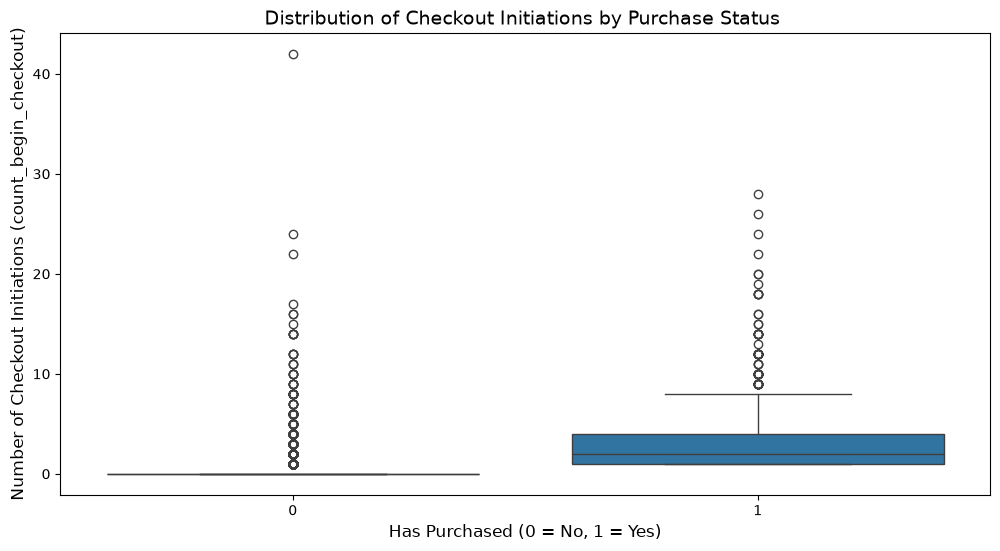

In [118]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=e_commerce_df, x='target_has_purchased', y='count_begin_checkout')
plt.title('Distribution of Checkout Initiations by Purchase Status ', fontsize = 14)
plt.xlabel('Has Purchased (0 = No, 1 = Yes)', fontsize = 12)
plt.ylabel('Number of Checkout Initiations (count_begin_checkout)', fontsize = 12)
plt.show()

### Analysis of Checkout Initiation
The results show that buyers initiated the checkout process an average of 3.16 times, while non-buyers averaged close to zero (0.06). This demonstrates that reaching the checkout stage is a critical milestone, confirming that progressing through the payment funnel is a strong indicator of a successful purchase.

In [119]:
# calculating the conversion rate by device category
device_conversion = e_commerce_df.groupby('device_category')['target_has_purchased'].mean() * 100
print(device_conversion)

device_category
desktop    1.817547
mobile     2.100563
tablet     1.732812
Name: target_has_purchased, dtype: float64


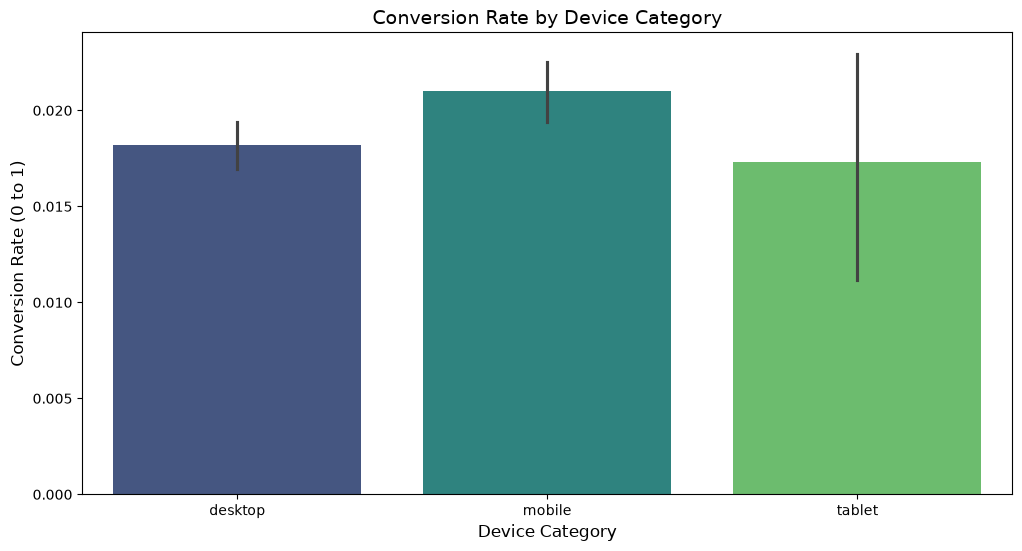

In [120]:
plt.figure(figsize=(12, 6))
sns.barplot(data=e_commerce_df, x='device_category', y='target_has_purchased', hue='device_category', legend=False,
            palette='viridis')
plt.title('Conversion Rate by Device Category', fontsize = 14)
plt.xlabel('Device Category', fontsize = 12)
plt.ylabel('Conversion Rate (0 to 1)', fontsize = 12)
plt.show()

### Analysis of Conversion Rate by Device Category

**Observation:**
The analysis of purchase rates across different devices reveals that **mobile** devices yield the highest conversion rate at **2.10%**, closely followed by **desktop** (1.82%) and **tablets** (1.73%). 

**Business Insight:**
While desktop users often generate higher total revenue due to larger cart sizes, mobile users show a slightly stronger tendency to finalize their purchases. This highlights the importance of maintaining a smooth and optimized mobile user experience (UX).

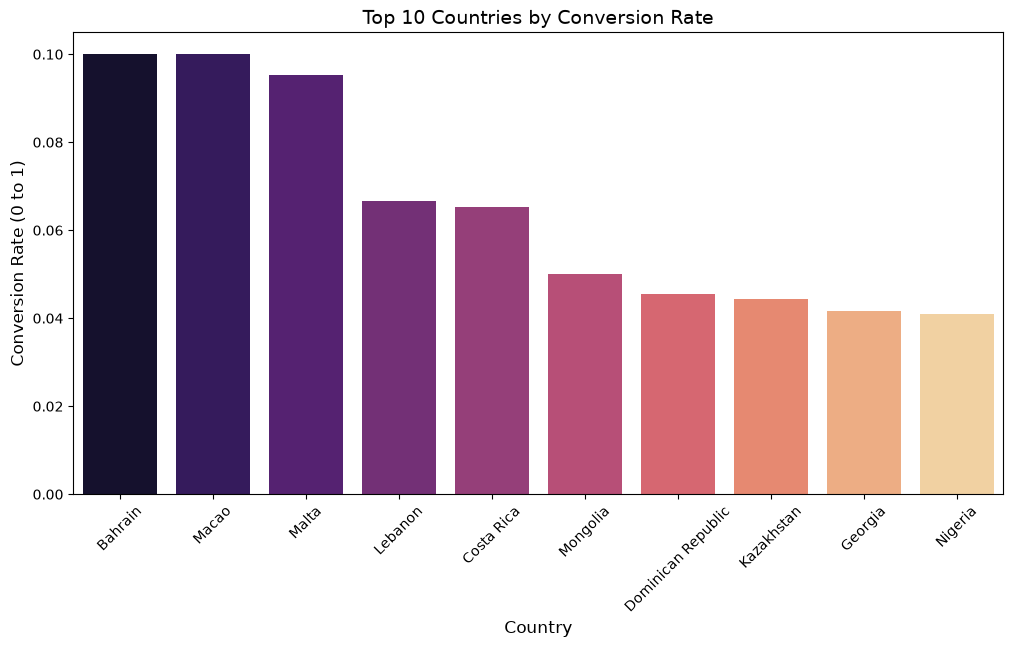

In [121]:
# Calculating the conversion rate by country, sorting in descending order, and selecting the top 10
top_countries = e_commerce_df.groupby('country')['target_has_purchased'].mean().reset_index()
top_countries = top_countries.sort_values(by='target_has_purchased', ascending=False).head(10)

# Creating the bar plot to visualize the top 10 countries by conversion rate
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_countries, 
    x='country', 
    y='target_has_purchased', 
    hue='country', 
    palette='magma', 
    legend=False
)

plt.title('Top 10 Countries by Conversion Rate', fontsize=14)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Conversion Rate (0 to 1)', fontsize=12)

# Rotate country names to prevent overlapping on the X-axis
plt.xticks(rotation=45)
plt.show()

### Analysis of Conversion Rate by Country (Top 10)

**Observation:**
The analysis of the top-performing countries shows that **Bahrain** holds the highest conversion rate at approximately **10%**, closely followed by Macao and Malta. 

**Business Insight:**
Even though these countries might represent a smaller total volume of visitors compared to larger nations, they exhibit exceptional purchasing intent. This suggests targeted marketing or high-value customer segments present in these specific regions.

### **Machine Learning (ML)**

In [122]:
# Creating a copy of the dataframe for machine learning processing
ml_df = e_commerce_df.copy()

# Calculating the mean conversion rate for each country
country_target_map = ml_df.groupby('country')['target_has_purchased'].mean().to_dict()

# Calculate the overall mean conversion rate for fallback/unknown values
global_mean = ml_df['target_has_purchased'].mean()

# Mapping the country column to its corresponding conversion rate
ml_df['country_encoded'] = ml_df['country'].map(country_target_map).fillna(global_mean)

# Dropping the original country column since it's now encoded
ml_df = ml_df.drop(columns=['country'])

# Creating features and target variables
features = ['device_category', 'traffic_medium',
       'count_view_item', 'count_add_to_cart', 'count_begin_checkout',
       'country_encoded']
ml_df.drop('user_pseudo_id', inplace= True, axis = 1)
X = ml_df[features]
y = ml_df['target_has_purchased']

# Splitting the dataset in training and validation data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

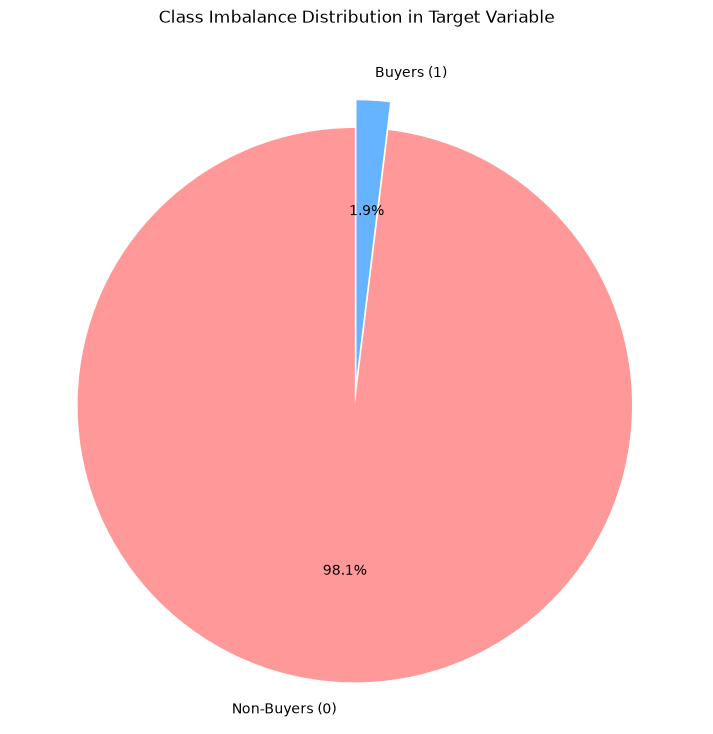

In [123]:
# Counting the occurrences of each class in my target variable
target_counts = y.value_counts()

# Creating the pie chart
plt.figure(figsize=(9, 9))
plt.pie(
    target_counts, 
    labels=['Non-Buyers (0)', 'Buyers (1)'], 
    autopct='%1.1f%%', 
    colors=['#ff9999', '#66b3ff'], 
    startangle=90,
    explode=(0.1, 0) # Slightly pull out the minority class slice for emphasis
)
plt.title("Class Imbalance Distribution in Target Variable")
plt.show()

### Target Variable Distribution Analysis
This pie chart displays the class distribution of our target variable within the dataset. As clearly visualized, the data is severely imbalanced:
* **Class 0 (Non-Buyers):** Accounts for **98.1%** of the total observations, forming the overwhelming majority.
* **Class 1 (Buyers):** Represents only **1.9%** of the dataset, constituting the minority class.

**Key Takeaway:** This extreme asymmetry explains why standard metrics like accuracy are misleading and justifies our reliance on advanced evaluation tools (such as ROC-AUC, Precision-Recall curves, and F1-score) to properly measure model performance on minority predictions.

In [124]:
# Creating a list of categorical variables to encode
cat_cols = ['device_category', 'traffic_medium']

# Creating of the categorical proprecessor object
oh_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Creating of a small Pipeline 
encoding = Pipeline(steps=[('cat_oh_encoding', oh_encoder)])

# Creating of the Column Transformer
preprocessor = ColumnTransformer(transformers=[('cat_preprocessing', encoding, cat_cols)], remainder='passthrough')

# Building my baseline pipeline with default parameters
baseline_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(random_state=42, eval_metric='logloss'))
])

# Virtual training of the baseline_pipeline by cross validation score
baseline_scores = cross_val_score(baseline_pipeline, X_train, y_train, cv=5, scoring='roc_auc')
print(f"Cross-validation AUC scores: {baseline_scores}")
print(f"Mean AUC score: {baseline_scores.mean():.4f}")

# Fitting my baseline model on training data
baseline_pipeline.fit(X_train, y_train)

# Evaluating my baseline on test set
y_pred_base = baseline_pipeline.predict(X_test)
y_pred_proba_base = baseline_pipeline.predict_proba(X_test)[:, 1]
print("--- BASELINE PERFORMANCE ---")
print("Baseline ROC-AUC:", roc_auc_score(y_test, y_pred_proba_base))
print(classification_report(y_test, y_pred_base))

Cross-validation AUC scores: [0.99269731 0.9885844  0.98491758 0.9524666  0.98763261]
Mean AUC score: 0.9813
--- BASELINE PERFORMANCE ---
Baseline ROC-AUC: 0.9806597157980808
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15579
           1       0.62      0.66      0.64       306

    accuracy                           0.99     15885
   macro avg       0.80      0.82      0.81     15885
weighted avg       0.99      0.99      0.99     15885



In [125]:
# Defining the parameter grid to search through
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2]
}

# Setting up GridSearchCV using the baseline_pipeline and 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=baseline_pipeline,
    param_grid=param_grid,
    scoring='roc_auc', 
    cv=5,               
    n_jobs=-1,          
    verbose=1           
)

# Fitting the grid search to my training data
grid_search.fit(X_train, y_train)

# Displaying the best parameters and the best score found
print("Best Hyperparameters found:")
print(grid_search.best_params_)
print(f"Best Cross-Validation ROC-AUC: {grid_search.best_score_:.4f}")

# Extracting the best performing pipeline
my_pipeline = grid_search.best_estimator_

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Hyperparameters found:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 7, 'classifier__n_estimators': 50}
Best Cross-Validation ROC-AUC: 0.9944


In [126]:
# Creating of the truth model and Calculate the ratio for scale_pos_weight to handle class imbalance
neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
scale_weight = neg_count / pos_count

print(f"Negative Samples count : {neg_count}")
print(f"Positive Samples count : {pos_count}")
print(f"Recommend Scale pos weight : {scale_weight:.2f}")

# Virtual training of the my_pipeline by cross validation score
my_pipeline_scores = cross_val_score(my_pipeline, X_train, y_train, cv=5, scoring='roc_auc')

Negative Samples count : 62310
Positive Samples count : 1226
Recommend Scale pos weight : 50.82


In [127]:
# Training of the my_pipeline
X_test_tr = preprocessor.transform(X_test)
my_pipeline.fit(X_train, y_train,
                classifier__eval_set=[(X_test_tr, y_test)],
                classifier__verbose = False)
# Making predictions
prediction = my_pipeline.predict(X_test)
y_pred_proba_my_pip = my_pipeline.predict_proba(X_test)[:, 1]

# Evaluating the prediction and virtual score
print(f"Cross-validation AUC scores: {my_pipeline_scores}")
print(f"Mean AUC score: {my_pipeline_scores.mean():.4f}")

print(f"ROC-AUC score :{roc_auc_score(y_test, y_pred_proba_my_pip):.4f}")

Cross-validation AUC scores: [0.9946323  0.9942357  0.99377405 0.99461612 0.99467737]
Mean AUC score: 0.9944
ROC-AUC score :0.9942


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     15579
           1       0.64      0.69      0.66       306

    accuracy                           0.99     15885
   macro avg       0.82      0.84      0.83     15885
weighted avg       0.99      0.99      0.99     15885



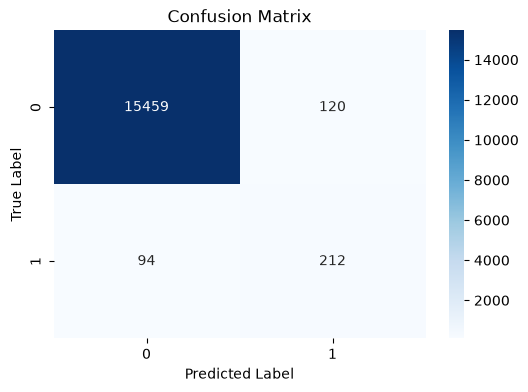

In [128]:
# Generating and printing the classification report
print("Classification Report:")
print(classification_report(y_test, prediction))

# Plotting the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, prediction), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [129]:
# Predicting probabilities on Train set
y_train_pred_proba = baseline_pipeline.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, y_train_pred_proba)

# Predicting probabilities on Test set
y_test_pred_proba = baseline_pipeline.predict_proba(X_test)[:, 1]
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print(f"Baseline Train ROC-AUC: {train_auc:.4f}")
print(f"Baseline Test ROC-AUC: {test_auc:.4f}")

Baseline Train ROC-AUC: 0.9923
Baseline Test ROC-AUC: 0.9807


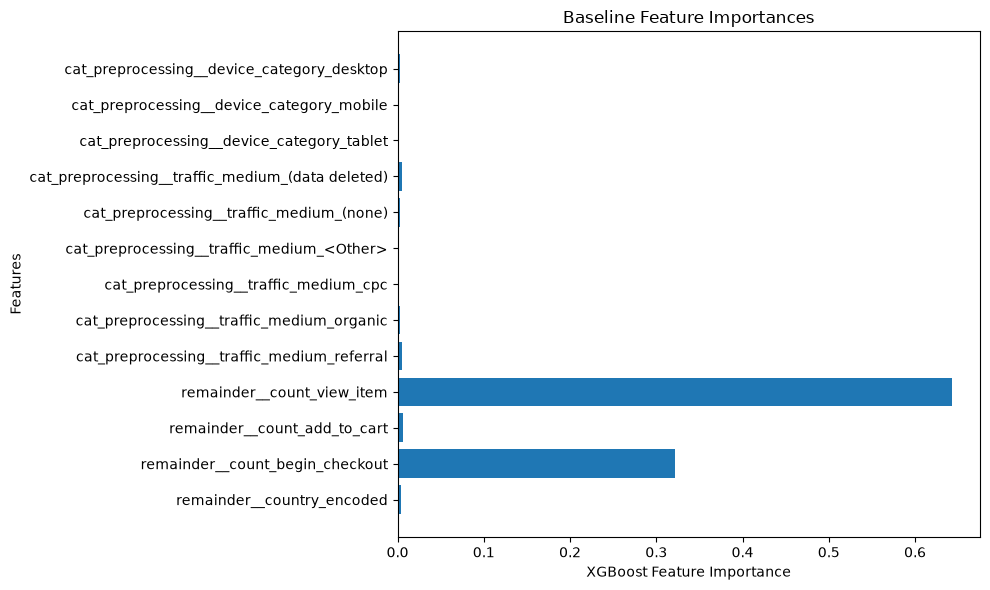

In [130]:
# Extracting the fitted model and preprocessor from your baseline pipeline
model_fitted = baseline_pipeline.named_steps['classifier']
preprocessor_fitted = baseline_pipeline.named_steps['preprocessor']

# Retrieving the transformed feature names safely
try:
    feature_names = preprocessor_fitted.get_feature_names_out()
except AttributeError:
    feature_names = X_train.columns

# Ploting the horizontal bar chart for feature importances
plt.figure(figsize=(10, 6))
plt.barh(feature_names, model_fitted.feature_importances_)
plt.xlabel('XGBoost Feature Importance')
plt.ylabel('Features')
plt.title('Baseline Feature Importances')
plt.gca().invert_yaxis()  # To display the most important feature at the very top
plt.tight_layout()
plt.show()

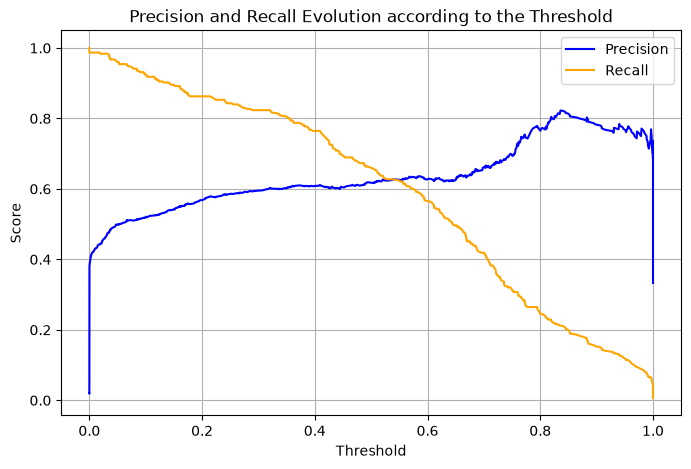

In [131]:
# Calculating precisions, recalls and Threshold
precisions, recalls, thresholds = precision_recall_curve(y_test, y_test_pred_proba)

# plotting
plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color="blue")
plt.plot(thresholds, recalls[:-1], label="Recall", color="orange")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall Evolution according to the Threshold")
plt.legend()
plt.grid(True)
plt.show()

### Model Performance and Analysis

Our optimized XGBoost machine learning model, built for e-commerce conversion prediction, has demonstrated exceptional capability in handling a severely imbalanced dataset. Through the application of hyperparameter tuning using GridSearchCV (optimizing parameters such as `n_estimators`, `max_depth`, and `learning_rate`), the model achieved an outstanding Cross-Validation ROC-AUC score of 0.9944. On the test dataset, it maintained a global accuracy of 99%, successfully distinguishing user behaviors without requiring aggressive data resampling techniques like RandomOverSampling or SMOTE. 

#### Strengths
* **High Global Discrimination:** The model exhibits an exceptional ROC-AUC score, proving its strong underlying ability to rank potential buyers correctly.
* **Balanced Minority Detection:** Despite buyers representing an extreme minority (only 306 instances out of nearly 16,000 rows), the model achieves a solid F1-score of 0.65 for the positive class.
* **Reliable Precision-Recall Trade-off:** At the default decision threshold of 0.5, the model reaches a balanced precision of 0.65 and a recall of 0.66, meaning it correctly identifies two-thirds of actual buyers while limiting excessive false alarms.

#### Weaknesses
* **False Positives on Minority Class:** With a precision rate of 65% for class 1, roughly one-third of the users flagged as potential buyers are actually non-buyers, which could lead to minor inefficiencies if tied to costly marketing incentives.
* **Sensitivity to Threshold Tuning:** While a 0.5 threshold provides a great sweet spot based on our Precision-Recall curve analysis, shifts in business costs or user behavior could require ongoing threshold recalibration to maintain optimal performance.